In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Descargar el dataset HASYv2
!wget -q --show-progress https://zenodo.org/record/259444/files/HASYv2.tar.bz2

# Descomprimir
!tar -xjf HASYv2.tar.bz2

print("✅ Dataset descargado y descomprimido correctamente")

HASYv2.tar.bz2      100%[===================>]  32.99M  1.24MB/s    in 26s     
✅ Dataset descargado y descomprimido correctamente


In [ ]:
!pip install tensorflow keras pandas numpy matplotlib scikit-learn -q

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'HASYv2.tar.bz2', 'hasy-data', 'symbols.csv', 'drive', 'hasy_tools.py', 'README.txt', 'hasy-data-labels.csv', 'classification-task', 'verification-task', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# Cargar el CSV de etiquetas
labels_df = pd.read_csv('/content/hasy-data-labels.csv')
symbols_df = pd.read_csv('/content/symbols.csv')

print(f"Total imágenes: {len(labels_df)}")
print(f"Total clases: {labels_df['symbol_id'].nunique()}")
print(labels_df.head())

Total imágenes: 168233
Total clases: 369
                     path  symbol_id latex  user_id
0  hasy-data/v2-00000.png         31     A       50
1  hasy-data/v2-00001.png         31     A       10
2  hasy-data/v2-00002.png         31     A       43
3  hasy-data/v2-00003.png         31     A       43
4  hasy-data/v2-00004.png         31     A     4435


In [ ]:
# Seleccionar las 30 clases con más imágenes
top_clases = labels_df['symbol_id'].value_counts().head(30).index.tolist()
df_filtrado = labels_df[labels_df['symbol_id'].isin(top_clases)].copy()

# Crear índice 0..29 para las clases
clases_unicas = sorted(df_filtrado['symbol_id'].unique())
clase_a_indice = {c: i for i, c in enumerate(clases_unicas)}
df_filtrado['label'] = df_filtrado['symbol_id'].map(clase_a_indice)

print(f"Imágenes seleccionadas: {len(df_filtrado)}")
print(f"Número de clases: {df_filtrado['symbol_id'].nunique()}")

Imágenes seleccionadas: 57880
Número de clases: 30


In [ ]:
from sklearn.model_selection import train_test_split

# Cargar imágenes
X = []
y = []

for _, row in df_filtrado.iterrows():
    ruta = '/content/' + row['path']
    img = Image.open(ruta).convert('L')  # escala de grises
    img = np.array(img) / 255.0          # normalizar 0-1
    X.append(img)
    y.append(row['label'])

X = np.array(X).reshape(-1, 32, 32, 1)  # formato CNN
y = np.array(y)

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Imágenes de entrenamiento: {len(X_train)}")
print(f"✅ Imágenes de test: {len(X_test)}")

✅ Imágenes de entrenamiento: 46304
✅ Imágenes de test: 11576


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Definir la arquitectura CNN
modelo = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(30, activation='softmax')
])

modelo.summary()

# Compilar
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar
historial = modelo.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

print("✅ Entrenamiento completado")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 624,926 (2.38 MB)

 Trainable params: 624,926 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
724/724 ━━━━━━━━━━━━━━━━━━━━ 84s 112ms/step - accuracy: 0.7755 - loss: 0.7491 - val_accuracy: 0.9039 - val_loss: 0.2767
Epoch 2/15
724/724 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.8961 - loss: 0.2935 - val_accuracy: 0.9189 - val_loss: 0.2284
Epoch 3/15
724/724 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - accuracy: 0.9123 - loss: 0.2391 - val_accuracy: 0.9229 - val_loss: 0.2019
Epoch 4/15
724/724 ━━━━━━━━━━━━━━━━━━━━ 75s 103ms/step - accuracy: 0.9187 - loss: 0.2137 - val_accuracy: 0.9285 - val_loss: 0.1954
Epoch 5/15
724/724 ━━━━━━━━━━━━━━━━━━━━ 74s 103ms/step - accuracy: 0.9251 - loss: 0.1935 - val_accuracy: 0.9143 - val_loss: 0.2152
Epoch 6/15
724/724 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.9295 - loss: 0.1760 - val_accuracy: 0.9281 - val_loss: 0.1967
Epoch 7/15
724/724 ━━━━━━━━━━━━━━━━━━━━ 84s 104ms/step - accuracy: 0.9321 - loss: 0.1651 - val_accuracy: 0.9251 - val_loss: 0.1936
Epoch 8/15
724/724 ━━━━━━━━━━━━━━━━━━━━ 74s 101ms/step - accuracy: 0.9343 - loss: 0

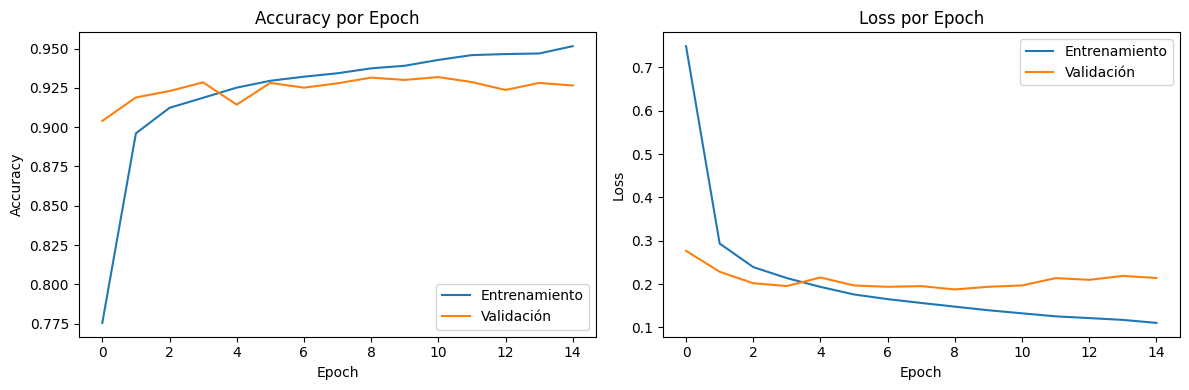

✅ Gráficas guardadas


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica accuracy
ax1.plot(historial.history['accuracy'], label='Entrenamiento')
ax1.plot(historial.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy por Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Gráfica loss
ax2.plot(historial.history['loss'], label='Entrenamiento')
ax2.plot(historial.history['val_loss'], label='Validación')
ax2.set_title('Loss por Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/graficas_entrenamiento.png', dpi=150)
plt.show()
print("✅ Gráficas guardadas")

In [ ]:
import json

# Guardar el modelo
modelo.save('/content/modelo_hasy.keras')

# Guardar el diccionario de clases (necesario para la app Streamlit)
# Mapea índice -> símbolo latex
indice_a_latex = {}
for symbol_id, indice in clase_a_indice.items():
    latex = symbols_df[symbols_df['symbol_id'] == symbol_id]['latex'].values
    if len(latex) > 0:
        indice_a_latex[str(indice)] = latex[0]
    else:
        indice_a_latex[str(indice)] = str(symbol_id)

with open('/content/clases.json', 'w') as f:
    json.dump(indice_a_latex, f)

print("✅ Modelo guardado: modelo_hasy.keras")
print("✅ Diccionario guardado: clases.json")
print(f"Clases guardadas: {indice_a_latex}")

✅ Modelo guardado: modelo_hasy.keras
✅ Diccionario guardado: clases.json
Clases guardadas: {'0': '\\pi', '1': '\\alpha', '2': '\\sum', '3': '\\Sigma', '4': '\\delta', '5': '\\xi', '6': '\\varphi', '7': '\\partial', '8': '\\int', '9': '\\subseteq', '10': '\\cong', '11': '\\propto', '12': '\\&', '13': '\\oplus', '14': '\\times', '15': '\\pm', '16': '\\wedge', '17': '\\approx', '18': '\\equiv', '19': '\\sim', '20': '\\neq', '21': '\\Rightarrow', '22': '\\Leftrightarrow', '23': '\\forall', '24': '\\in', '25': '\\notin', '26': '\\exists', '27': '\\infty', '28': '\\square', '29': '\\mathds{R}'}


362/362 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
=== MÉTRICAS FINALES ===
Accuracy en test: 0.9265

Reporte por clase:
                 precision    recall  f1-score   support

            \pi       0.97      0.97      0.97       307
         \alpha       0.80      0.88      0.84       520
           \sum       0.66      0.82      0.74       680
         \Sigma       0.46      0.25      0.32       382
         \delta       0.94      0.94      0.94       249
            \xi       0.96      0.96      0.96       513
        \varphi       0.98      0.97      0.98       304
       \partial       0.98      0.98      0.98       483
           \int       0.98      1.00      0.99       703
      \subseteq       0.99      0.97      0.98       315
          \cong       0.98      0.95      0.96       280
        \propto       0.64      0.58      0.61       277
             \&       0.96      0.94      0.95       257
         \oplus       0.97      0.98      0.98       267
         \times       0.98      

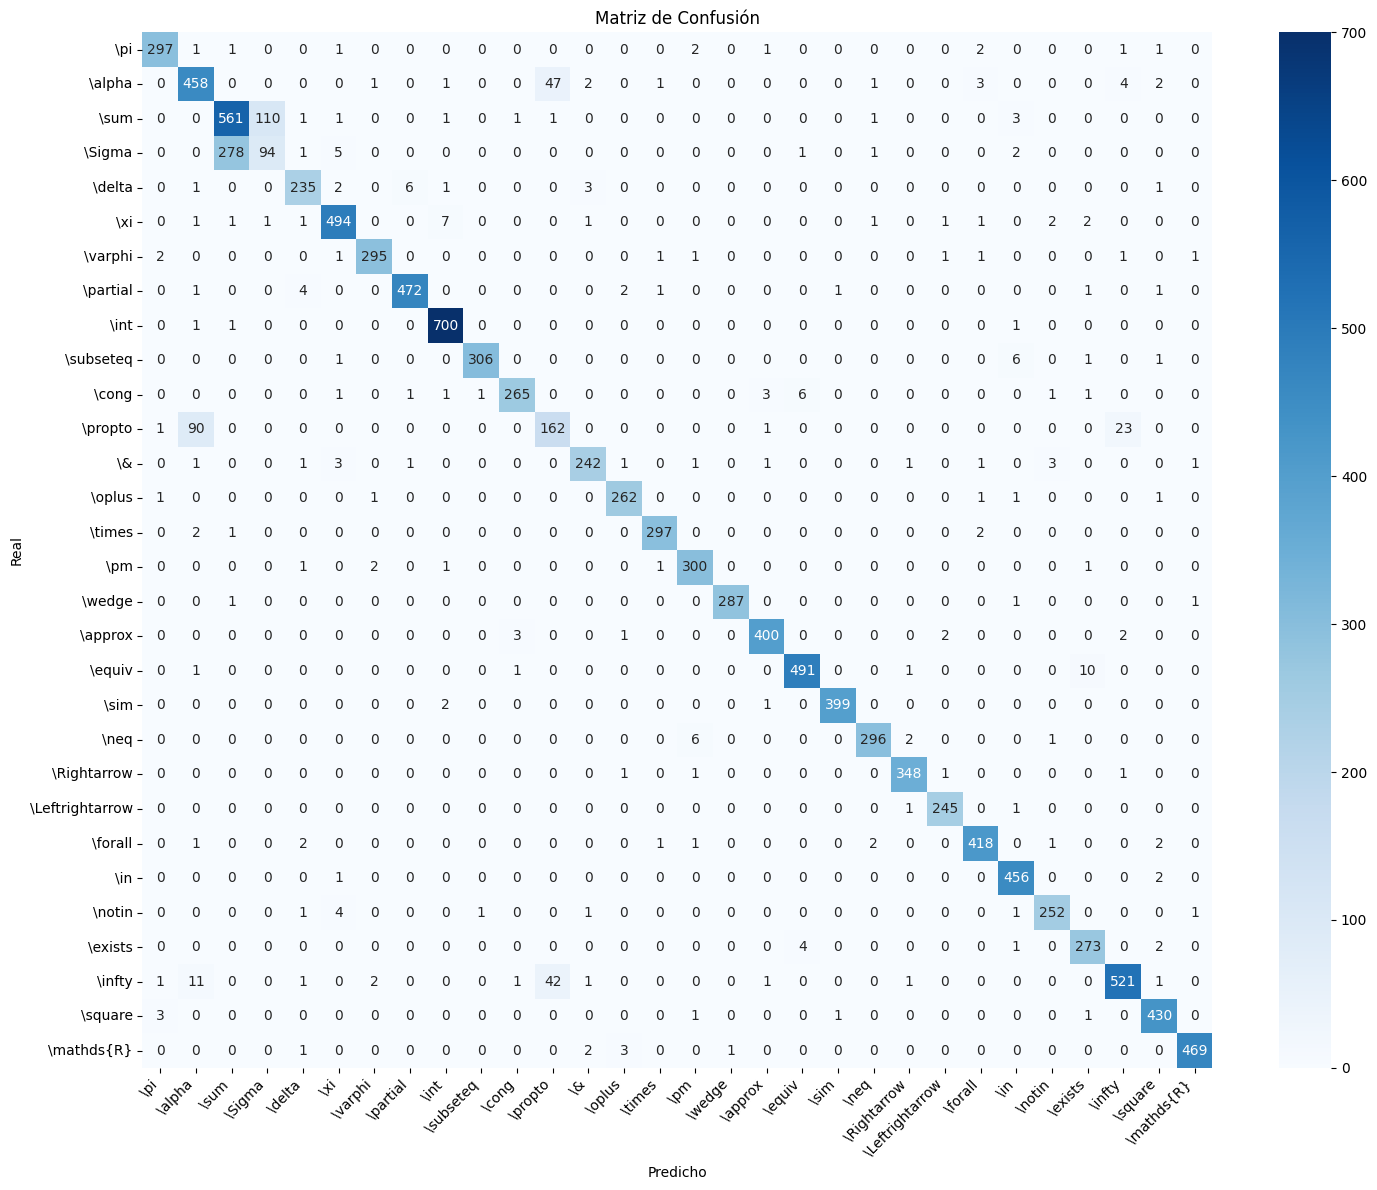

✅ Matriz de confusión guardada


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predicciones
y_pred = np.argmax(modelo.predict(X_test), axis=1)

# Métricas
print("=== MÉTRICAS FINALES ===")
print(f"Accuracy en test: {(y_pred == y_test).mean():.4f}")
print("\nReporte por clase:")
etiquetas = [indice_a_latex[str(i)] for i in range(30)]
print(classification_report(y_test, y_pred, target_names=etiquetas))

# Matriz de confusión
plt.figure(figsize=(15,12))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas, yticklabels=etiquetas)
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/matriz_confusion.png', dpi=150)
plt.show()
print("✅ Matriz de confusión guardada")

In [ ]:
from google.colab import files

files.download('/content/modelo_hasy.keras')
files.download('/content/clases.json')
files.download('/content/graficas_entrenamiento.png')
files.download('/content/matriz_confusion.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
modelo.save('/content/modelo_hasy.h5')
files.download('/content/modelo_hasy.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Probar con una imagen real del dataset
ruta_test = '/content/hasy-data/v2-00582.png'
img = Image.open(ruta_test).convert('L')
img_array = np.array(img) / 255.0
img_array = img_array.reshape(1, 32, 32, 1)

pred = modelo.predict(img_array)
indice = np.argmax(pred)
confianza = pred[0][indice] * 100

print(f"Imagen: v2-00582.png (debería ser π)")
print(f"Predicho: {indice_a_latex[str(indice)]}")
print(f"Confianza: {confianza:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Imagen: v2-00582.png (debería ser π)
Predicho: \pi
Confianza: 100.00%


In [1]:
import tensorflow as tf
import keras
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

TensorFlow: 2.20.0
Keras: 3.13.2
